## **Acerca de este conjunto de datos**

### **Contexto:**
Este conjunto de datos es útil para analizar las tendencias en la industria automotriz, como la identificación de modelos populares, la demanda regional y los patrones de precios. Permite elaborar modelos proyectivos de precios de automóviles, comparar las ventas de vehículos nuevos y usados, y comprender las prioridades de los clientes a lo largo del tiempo. Los datos pueden provenir de registros de concesionarios, mercados en línea o sitios web especializados en automóviles, en el mercado de Estados Unidos.

### **Contenido:**
El conjunto de datos de ventas de automóviles incluye información detallada sobre el comercio de vehículos individuales. Contiene columnas como fabricante, modelo, cilindrada, tipo de combustible, año de fabricación, kilometraje y precio.


### **Descripción de la columna:**
Este conjunto de datos contiene 5000 filas y 7 columnas. Los atributos clave que se suelen encontrar en el conjunto de datos son:

* **Fabricante:** Ford, Porsche, Toyota, VW y BMW, etc.

* **Modelo:** 718 Cayman, Mondeo, RAV4, Polo, Focus, etc.

* **Cilindrada:** 1, 4, 1.6, 1.8, etc.

* **Tipo de combustible:** Gasolina, diésel, híbrido

* **Año de fabricación:** 1990 en adelante

* **Kilometraje:** 127300, 57850, 39190, 210814, etc.

* **Precio ($):** 3074, 49704, 24072, 1705, etc.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/car_sales_data.csv')

In [ ]:
df.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


Cargamos los datos:

* **Manufacturer**, **Model** y **Fuel type** son variables categóricas nominales, ya que representan categorías o etiquetas sin un orden inherente entre sus valores.

* **Engine size** es una variable numérica continua, dado que corresponde a una medición física del tamaño del motor. En este caso, las diferencias entre los valores son significativas y pueden ser utilizadas directamente por los modelos de aprendizaje automático.

* **Year of manufacture** es una variable numérica discreta, puesto que toma valores enteros asociados al año de fabricación del vehículo.

* **Mileage** es una variable numérica continua que representa el kilometraje recorrido por el vehículo.

* **Price** es una variable numérica continua y corresponde a la variable objetivo del modelo, ya que es el valor que se busca predecir.

In [ ]:
columns ={'Manufacturer':'Fabricante',
          'Model': 'Modelo',
          'Engine size': 'Motor',
          'Year of manufacture':'Año',
          'Mileage':'Kilometraje',
          'Fuel type':'Combustible',
          'Price':'Precio'}

In [ ]:
df = df.rename(columns = columns)

In [ ]:
df.columns

Index(['Fabricante', 'Modelo', 'Motor', 'Combustible', 'Año', 'Kilometraje',
       'Precio'],
      dtype='object')

Por temas de mayor comodidad opte por cambiar el nombre de las variables a nuestro idioma con el fin que sea mas entendible.

## **¿Existe un predominio de marcas generalistas frente a marcas premium en el conjunto de datos, y cómo podría esta distribución influir en la predicción del precio del vehículo?**

In [ ]:
def pie(feature,title,explode,colors):

    serie = feature.value_counts()


    serie.plot(kind='pie',title=title, figsize=[20,8],
                     colors=colors,explode=explode,
          autopct=lambda p: '{:.2f}%({:.0f})'.format(p,(p/100)*serie.sum()))

In [ ]:
sns.set_style("whitegrid")

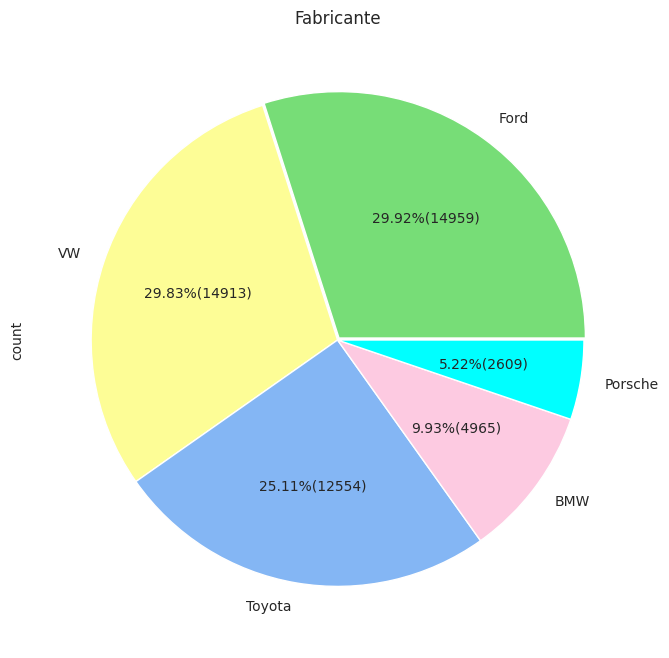

In [ ]:
colors=['#77dd77','#fdfd96','#84b6f4','#fdcae1','#00ffff']
explode= [0.01,0,0,0,0]
pie(df.Fabricante,'Fabricante',explode,colors)

* Mediante una gráfica de pastel se observa que las marcas generalistas, como Toyota, Ford y Volkswagen, concentran más del 85 % del conjunto de datos. Este comportamiento es esperable, ya que este tipo de fabricantes ofrece vehículos en distintas gamas y rangos de precio, lo que incrementa su presencia en el mercado y, por ende, en el dataset.

* Por el contrario, las marcas premium, como BMW o Porsche, presentan una menor representación, debido a que se enfocan en un segmento de consumidores con mayor poder adquisitivo y un volumen de ventas naturalmente más reducido.

In [ ]:
def barh(feature,title_,xlabel_,ylabel_,r):

  plt.figure(figsize=(10,5))
  serie =  df.groupby(feature) \
    .agg({'Precio':'mean'}) \
    .sort_values('Precio',
                 ascending = True)

  bars = plt.barh(
      serie.index,
      serie.Precio,
      color = "#29b4dc"
  )

  if r == True:

    plt.bar_label(bars)
    plt.title(title_)
    plt.xlabel(xlabel_)
    plt.ylabel(ylabel_)
    plt.show()


  else:
    plt.title(title_)
    plt.xlabel(xlabel_)
    plt.ylabel(ylabel_)
    plt.show()





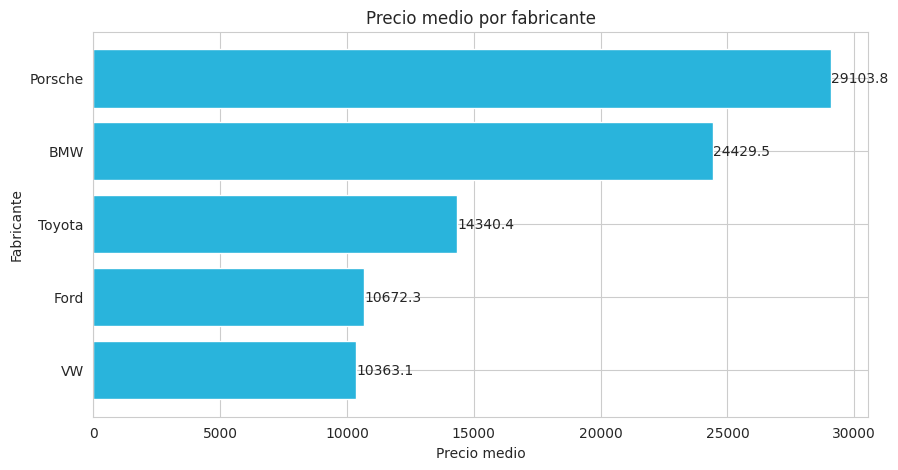

In [ ]:
barh('Fabricante','Precio medio por fabricante','Precio medio','Fabricante',True)

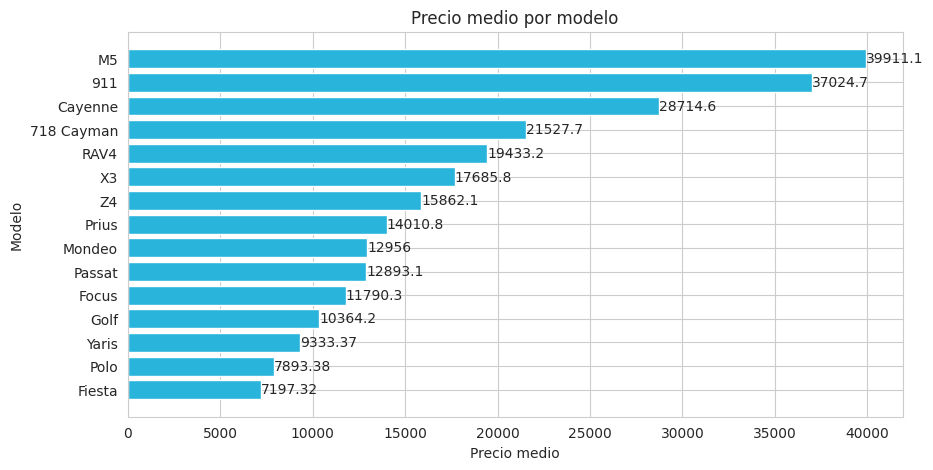

In [ ]:
barh('Modelo','Precio medio por modelo','Precio medio','Modelo',True)

* La **marca** y el **modelo** del vehículo influyen de manera significativa en su precio de mercado, ya que incorporan factores como posicionamiento, prestigio, nivel de equipamiento, desempeño y percepción de calidad. Por esta razón, no es adecuado comparar directamente el precio de vehículos pertenecientes a segmentos distintos, como un Porsche 911 y un Toyota Corolla, dado que responden a públicos objetivos, costos de producción y propuestas de valor completamente diferentes.

* En consecuencia, las variables **Fabricante**  y **Modelo** resultan fundamentales dentro del proceso de modelado, ya que permiten al algoritmo capturar las diferencias estructurales entre segmentos de mercado. Ignorar estas variables podría introducir sesgos y reducir significativamente la capacidad predictiva del modelo.

## **¿En qué medida el año de fabricación y el kilometraje contribuyen a la variabilidad del precio del vehículo?**

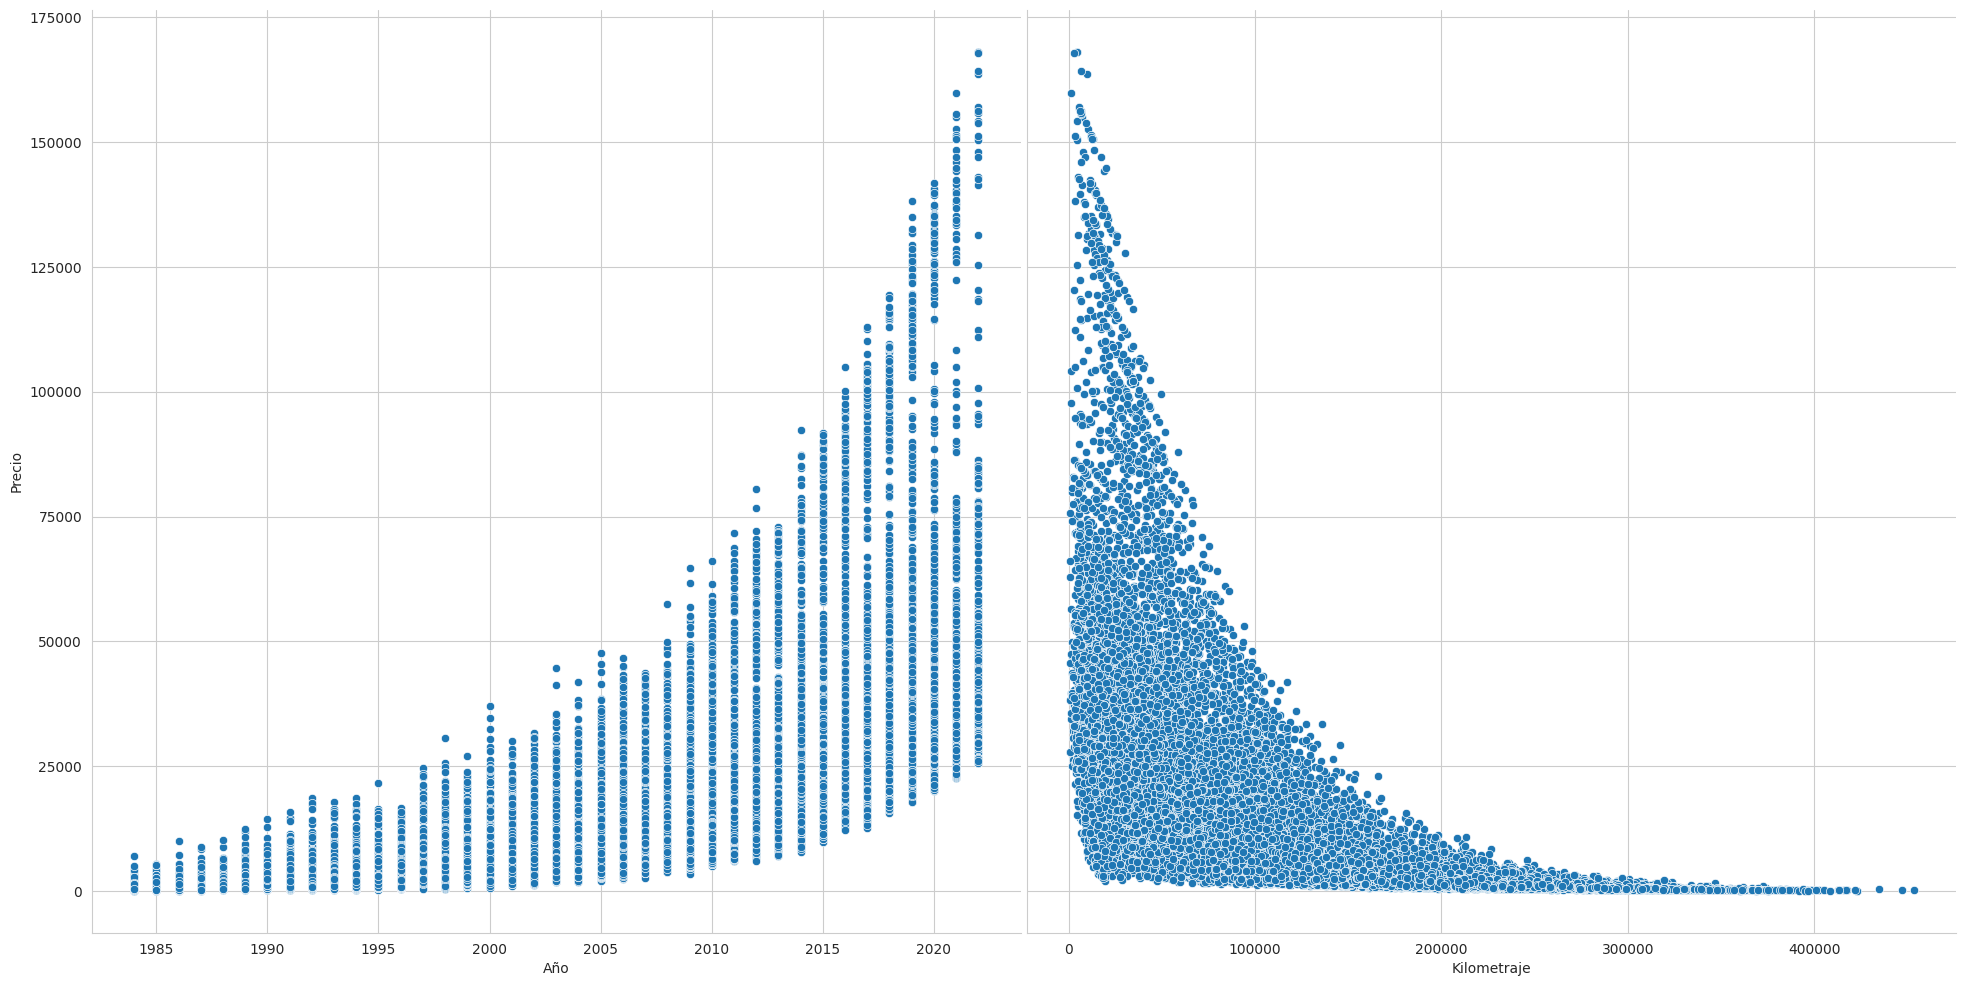

In [ ]:
sns.pairplot(
    data=df,
    x_vars=['Año', 'Kilometraje'],
    y_vars=['Precio'],
    kind='scatter',
    height=10,
    aspect=1
)

plt.show()

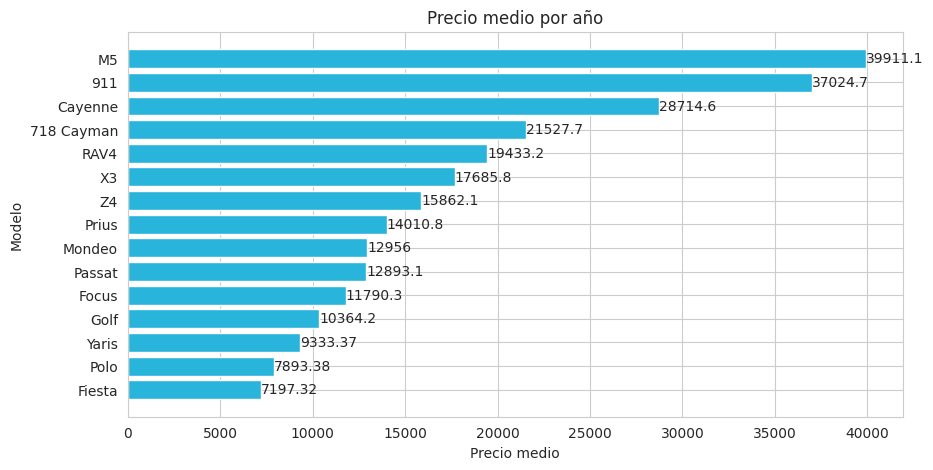

In [ ]:
barh('Modelo','Precio medio por año','Precio medio','Modelo',True)

* Es de esperar que la variable año de fabricación influya directamente en el precio del vehículo, ya que los modelos más recientes suelen incorporar mejoras tecnológicas, mayor nivel de equipamiento y mayores costos de producción, además de reflejar los efectos de la inflación a lo largo del tiempo.

* Por otro lado, la variable kilometraje presenta una relación inversa con el precio, dado que un mayor kilometraje implica un mayor desgaste mecánico, mayor tiempo de uso y, en consecuencia, una depreciación más pronunciada al momento de la venta.

* Estas relaciones son consistentes con el comportamiento observado en el mercado automotriz y justifican la inclusión de ambas variables como predictores relevantes dentro del modelo de estimación de precios.

## **¿En qué medida la cilindrada del motor contribuye a explicar la variabilidad del precio del vehículo en comparación con otras variables?**

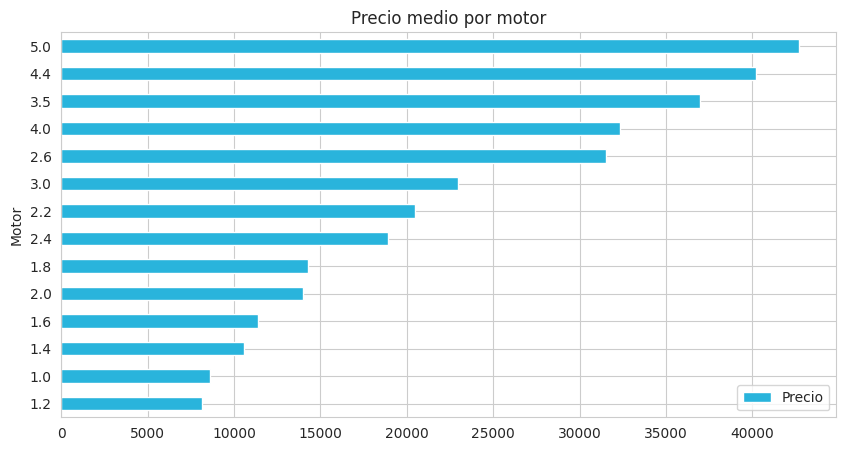

In [ ]:
df.groupby('Motor') \
.agg({'Precio':'mean'}) \
.sort_values('Precio',ascending=True) \
.plot(kind = "barh",color='#29b4dc',figsize=(10,5))
plt.title('Precio medio por motor')
plt.show()

* Al calcular el precio promedio en función de la cilindrada del motor, se observa que, en general, los vehículos con mayor cilindrada tienden a presentar un valor promedio más elevado. Este comportamiento puede explicarse por el hecho de que motores de mayor tamaño suelen ofrecer mayores prestaciones mecánicas, como mayor potencia y desempeño.

* No obstante, la cilindrada del motor no constituye una variable determinante por sí sola, ya que factores como el año de fabricación y el kilometraje ejercen una influencia más significativa sobre el precio del vehículo. En este sentido, la cilindrada actúa como una variable complementaria, que contribuye a explicar la variabilidad del precio cuando se analiza en conjunto con otras características del vehículo.

## **¿Cómo varía el precio del vehículo en función del tipo de combustible?**

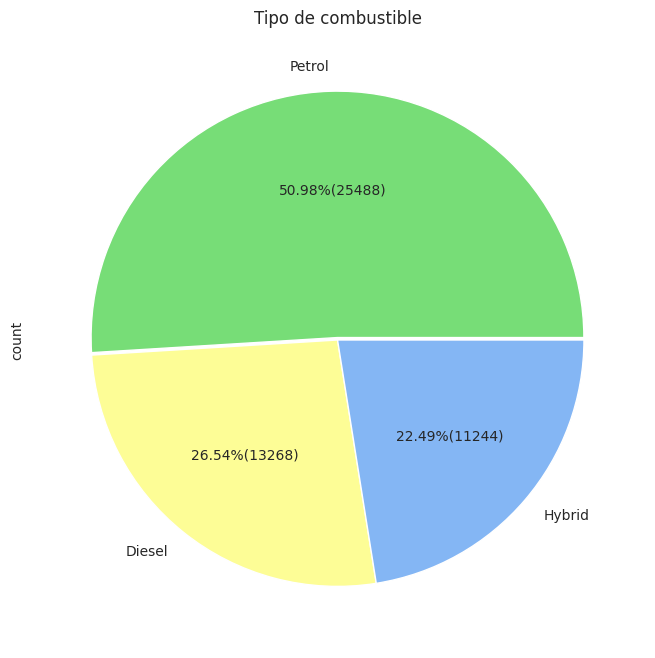

In [ ]:
colors=['#77dd77','#fdfd96','#84b6f4','#fdcae1','#00ffff']
explode= [0.01,0,0]
pie(df.Combustible,'Tipo de combustible',explode=explode,colors = colors)

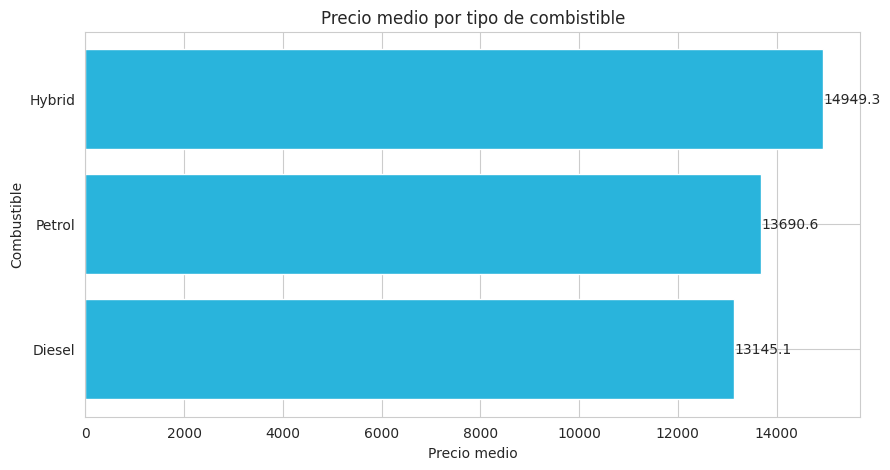

In [ ]:
barh('Combustible','Precio medio por tipo de combistible','Precio medio','Combustible',True)

* Al comparar el precio promedio en función del tipo de combustible (gasolina, diésel o híbrido), se observa que esta variable no presenta una influencia directa y determinante sobre el precio del vehículo dentro del conjunto de datos analizado.

* Si bien pueden existir diferencias puntuales entre tipos de combustible, estas no resultan tan significativas como las asociadas a variables como el año de fabricación, el kilometraje o el segmento del vehículo. En este contexto, el tipo de combustible actúa como una variable secundaria o complementaria, cuyo efecto sobre el precio suele estar condicionado por otras características del automóvil, como la marca, el modelo y el nivel de equipamiento.

## **Distribución del precio y kilometraje**

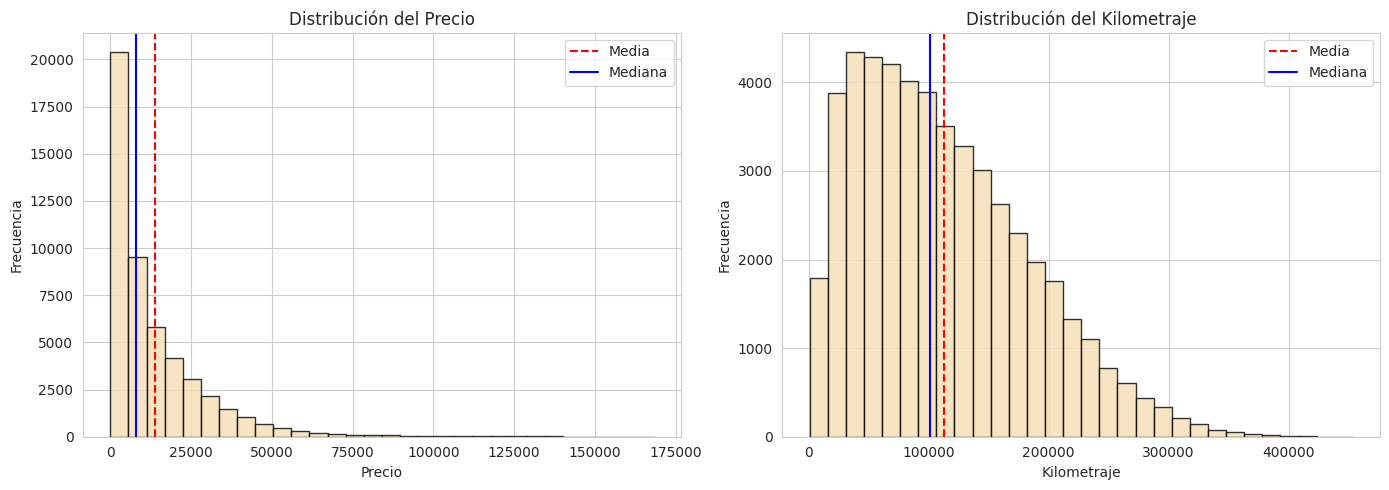

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))


axes[0].hist(
    df.Precio,
    bins=30,
    color='#f5deb3',
    edgecolor='black',
    alpha=0.8
)


axes[0].axvline(df.Precio.mean(), color='red', linestyle='--', label='Media')
axes[0].axvline(df.Precio.median(), color='blue', linestyle='-', label='Mediana')

axes[0].set_title('Distribución del Precio')
axes[0].set_xlabel('Precio')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()


axes[1].hist(
    df.Kilometraje,
    bins=30,
    color='#f5deb3',
    edgecolor='black',
    alpha=0.8
)


axes[1].axvline(df.Kilometraje.mean(), color='red', linestyle='--', label='Media')
axes[1].axvline(df.Kilometraje.median(), color='blue', linestyle='-', label='Mediana')

axes[1].set_title('Distribución del Kilometraje')
axes[1].set_xlabel('Kilometraje')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

* Al analizar el histograma del precio de los vehículos se observa una distribución fuertemente sesgada a la derecha, lo que indica que los datos no siguen una distribución normal. La mayor parte de los precios se concentra en rangos bajos y medios, mientras que una pequeña proporción de observaciones se extiende hacia valores elevados. Estos valores superiores a los 75,000 dólares no corresponden a errores en los datos, sino a modelos de vehículos de lujo, por lo que cuentan con una explicación lógica dentro del contexto del negocio y no deben eliminarse de manera automática.

* Ante este tipo de distribución, una práctica común es aplicar una transformación logarítmica a la variable objetivo, lo que permite reducir la asimetría, suavizar los valores extremos y estabilizar la varianza. Esta transformación no altera la naturaleza del fenómeno, sino que cambia la escala de análisis, facilitando el entrenamiento de modelos de regresión y mejorando su desempeño e interpretación en etapas posteriores del proyecto

* Al analizar la variable de kilometraje se observa una distribución con una ligera cola hacia la derecha, lo que indica que la mayoría de los vehículos presenta recorridos moderados, mientras que solo una pequeña proporción supera las 300,000 millas. Estos casos corresponden a vehículos con un uso intensivo a lo largo del tiempo y no representan necesariamente errores en los datos. Al igual que en el análisis del precio, es fundamental evaluar estos valores desde la perspectiva del negocio antes de decidir su eliminación.

## **Conclusión**



A partir del análisis exploratorio de los datos, se identifica que las variables con mayor influencia en el precio del vehículo son el kilometraje y el año de fabricación. El kilometraje impacta de manera inversa en el precio, ya que un mayor número de millas recorridas implica mayor desgaste mecánico y tiempo de uso, lo que naturalmente reduce el valor de mercado del vehículo.

Por su parte, el año de fabricación influye de forma directa en el precio, debido a factores como la inflación, el aumento en los costos de producción y la incorporación de mayor equipamiento y tecnología en los modelos más recientes.

Adicionalmente, se identifican variables complementarias, como la cilindrada del motor, que contribuyen a explicar la variabilidad del precio. En general, versiones con motores de mayor desplazamiento suelen ofrecer mejores prestaciones mecánicas, lo que se refleja en precios más elevados; por ejemplo, un modelo equipado con un motor 3.6 V6 suele tener un valor superior al de una versión 2.5 litros, aun perteneciendo al mismo modelo.

Finalmente, variables como el tipo de combustible no resultan determinantes de manera aislada, aunque pueden aportar información adicional al modelo cuando se analizan en conjunto con el resto de las características del vehículo.